# 02 — Leakage-safe feature engineering

## Purpose of this notebook

The prepared data contain final scores and match statistics. They are useful for describing past performance, but they are not automatically valid predictors. This notebook transforms them into variables that would have been known before each match.

The mathematical information rule is

$$
F_{i,j} \in \mathcal{I}_{i}^{-},
$$

where $F_{i,j}$ is feature $j$ for match $i$ and $\mathcal{I}_{i}^{-}$ is the information available strictly before match $i$. Consequently, the goals, points, xG, PPDA, or any other statistic generated in match $i$ cannot be used to predict match $i$.

This notebook has five objectives:

1. explain how every feature family is calculated;
2. show why the calculation is relevant to football prediction;
3. verify the lag and information cut-off visibly;
4. print a complete catalogue of all candidate variables;
5. save one CSV candidate table for the modelling notebooks.

No feature is selected here. Feature selection is estimated separately inside the chronological development folds in Notebooks 03 and 05.

## 1. Sources inherited from Notebook 01

The feature table combines downloaded variables and variables calculated in this project:

| Feature family | Original source | Information boundary |
|---|---|---|
| Result form, goals, points, xG, non-penalty xG, expected points, PPDA, deep completions | [Understat](https://understat.com/) through [soccerdata](https://soccerdata.readthedocs.io/) | Only completed earlier matches are included |
| Internal Elo and league context | Calculated here from previous Understat results | Ratings and rates are recorded before the current update |
| ClubElo | [ClubElo](http://clubelo.com/) | Rating interval valid on the match date |
| Squad strength | Public [FIFA 15–FC 24](https://www.kaggle.com/datasets/stefanoleone992/ea-sports-fc-24-complete-player-dataset) and [FC 25](https://www.kaggle.com/datasets/nyagami/ea-sports-fc-25-database-ratings-and-stats) player data | Latest public team snapshot dated on or before the match |
| Market probabilities | [Football-Data](https://www.football-data.co.uk/data.php) | Archived pre-match or closing odds; exact intraday timestamp is not available for every match |

Understat's xG and expected-points variables describe the quality of chances rather than only the realised score. PPDA approximates pressing intensity, while deep completions describe progression close to the opponent's goal. These measures may contain signal that is hidden by the randomness of goals, but they are provider-dependent estimates rather than error-free physical quantities.

## 2. Setup and fixed modelling period

The oldest modelling season is 2021/22. Earlier rows from Notebook 01 are not used to initialise form or internal Elo in this experiment. This implements the agreed recent-history design and avoids carrying a long, structurally different football period into the model through engineered states.

The feature table contains development seasons 2021/22–2023/24 and the final walk-forward season 2024/25. Rows after 2024/25 are outside the thesis experiment and are excluded.

In [1]:
from pathlib import Path
import os
import re
import sys
import tempfile

os.environ.setdefault(
    "MPLCONFIGDIR",
    str(Path(tempfile.gettempdir()) / "match_prediction_matplotlib"),
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import FINAL_TEST_SEASON, INTERIM_DATA_DIR, MODELLING_START_SEASON, PROCESSED_DATA_DIR
from src.feature_engineering import (
    BASIC_METRICS,
    RICH_METRICS,
    VENUE_METRICS,
    build_feature_table,
    get_feature_sets,
)

pd.set_option("display.max_columns", 35)
pd.set_option("display.max_rows", 260)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 100)

CLASS_COLORS = {"H": "#2A9D8F", "D": "#8D99AE", "A": "#C44E52"}
FAMILY_COLORS = {
    "Structural": "#1F4E79",
    "Market": "#E9C46A",
    "External": "#2A9D8F",
}

matches = pd.read_csv(INTERIM_DATA_DIR / "base_matches.csv", parse_dates=["date"])
study_matches = matches.loc[
    matches["season_id"].between(MODELLING_START_SEASON, FINAL_TEST_SEASON)
].copy()

print(f"Input rows in the fixed experiment: {len(study_matches):,}")
print(f"Seasons: {sorted(study_matches['season_id'].unique())}")
study_matches[
    ["league_id", "season_id", "date", "home_team", "away_team", "target_1x2", "sample_role"]
].sample(6, random_state=42).sort_values(["season_id", "date"])

Input rows in the fixed experiment: 7,156
Seasons: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


,league_id,season_id,date,home_team,away_team,target_1x2,sample_role
17904,SERIE_A,2021,2021-09-22,Salernitana,Verona,D,development
18255,SERIE_A,2022,2022-08-21,Napoli,Monza,H,development
18307,SERIE_A,2022,2022-09-18,Fiorentina,Verona,H,development
10267,LALIGA,2022,2022-10-01,Cadiz,Villarreal,D,development
10883,LALIGA,2023,2024-03-31,Real Madrid,Athletic Club,H,development
6766,EPL,2023,2024-05-11,Newcastle United,Brighton,D,development


The sample confirms that only the four fixed seasons enter feature construction. Outcomes are present because they update the state after a match and provide later modelling targets; they are not members of either candidate input set.

## 3. Long team representation

One match is first written as two chronological observations: one from the home team's perspective and one from the away team's perspective. For team $c$ in match time $t$, the common variables become `goals_for`, `goals_against`, `points`, `xg_for`, `xg_against`, and analogous measures. This representation makes the lag operation transparent and avoids writing separate rolling logic for home and away teams.

Let $z_{c,t}$ denote one observed performance measure of team $c$ in its $t$-th match. A rolling mean based on the last $w$ completed matches is

$$
\bar z_{c,t}^{(w)}
=
\frac{1}{m_{c,t}}
\sum_{r=1}^{m_{c,t}} z_{c,t-r},
\qquad
m_{c,t}=\min(w,n_{c,t}^{-}).
$$

The symbols mean:

- $w\in\{5,10\}$ is the maximum window length;
- $n_{c,t}^{-}$ is the number of eligible earlier matches in the current top-flight spell;
- $m_{c,t}$ is the number actually available;
- $r=1$ identifies the immediately preceding match;
- the current observation $z_{c,t}$ is absent from the sum.

The five-match version reacts more quickly to recent form. The ten-match version is more stable but slower to recognise a real change. Using both creates candidate variables; chronological feature selection later decides whether both are useful.

### 3.1 Exponentially weighted form

An exponentially weighted mean gives the most recent completed match the greatest weight:

$$
e_{c,t}^{(s)}
=
\alpha z_{c,t-1}
+(1-\alpha)e_{c,t-1}^{(s)},
\qquad
\alpha=\frac{2}{s+1},
\qquad s=5.
$$

Here, $e_{c,t}^{(s)}$ is the pre-match exponentially weighted state and $s$ is the span. For $s=5$, $\alpha=1/3$. This smooths random match-to-match variation while responding faster than a full-season mean. Its limitation is that the interpretation is less direct than “the average of the last five matches”.

### 3.2 Season and venue form

The season-to-date mean is

$$
\bar z_{c,t}^{(S)}
=
\frac{1}{n_{c,t}^{(S)}}
\sum_{r<t\,:\,S_r=S_t} z_{c,r},
$$

where $S_t$ is the current season and $n_{c,t}^{(S)}$ counts the team's earlier matches in that season. It resets at the start of every season.

For selected variables, a five-match venue mean is calculated using only earlier home matches for the current home team or earlier away matches for the current away team. Venue-specific form may represent tactical or environmental differences, but it uses fewer observations and is therefore noisier early in a season.

### 3.3 Base performance measures

The same transformations are applied to several football quantities. The table defines their direction and intended interpretation before the code creates any combinations.

In [2]:
metric_dictionary = pd.DataFrame(
    [
        ("goals_for", "Final score / Understat", "Realised attacking output", "More is normally stronger"),
        ("goals_against", "Final score / Understat", "Realised defensive outcome", "Less is normally stronger"),
        ("points", "Calculated from final score", "Realised match success: 3, 1, or 0", "More is stronger"),
        ("goal_diff", "Calculated: goals for − goals against", "Combined realised attack and defence", "More is stronger"),
        ("xg_for", "Understat", "Quality of chances created", "More is normally stronger"),
        ("xg_against", "Understat", "Quality of chances conceded", "Less is normally stronger"),
        ("xg_diff", "Calculated: xG for − xG against", "Chance-quality balance", "More is stronger"),
        ("np_xg_for", "Understat", "Non-penalty chance quality created", "More is normally stronger"),
        ("np_xg_against", "Understat", "Non-penalty chance quality conceded", "Less is normally stronger"),
        ("np_xg_diff", "Calculated: non-penalty xG for − against", "Open-play chance-quality balance", "More is stronger"),
        ("expected_points", "Understat", "Expected reward from the chance distribution", "More is normally stronger"),
        ("ppda", "Understat", "Opponent passes allowed per defensive action", "Lower often means more intense pressing"),
        ("deep_completions", "Understat", "Completed actions close to the opponent's goal", "More suggests territorial threat"),
    ],
    columns=["metric", "source_or_calculation", "intended_role", "usual_direction"],
)
metric_dictionary

,metric,source_or_calculation,intended_role,usual_direction
0,goals_for,Final score / Understat,Realised attacking output,More is normally stronger
1,goals_against,Final score / Understat,Realised defensive outcome,Less is normally stronger
2,points,Calculated from final score,"Realised match success: 3, 1, or 0",More is stronger
3,goal_diff,Calculated: goals for − goals against,Combined realised attack and defence,More is stronger
4,xg_for,Understat,Quality of chances created,More is normally stronger
5,xg_against,Understat,Quality of chances conceded,Less is normally stronger
6,xg_diff,Calculated: xG for − xG against,Chance-quality balance,More is stronger
7,np_xg_for,Understat,Non-penalty chance quality created,More is normally stronger
8,np_xg_against,Understat,Non-penalty chance quality conceded,Less is normally stronger
9,np_xg_diff,Calculated: non-penalty xG for − against,Open-play chance-quality balance,More is stronger


The expected directions are football interpretations, not restrictions imposed on a model. PPDA is especially context-dependent: a low value can indicate strong pressing, but also a tactical choice that is not universally superior.

## 4. Build all pre-match states

The reusable function performs the calculations just defined. Within each team and top-flight spell, every rolling input is shifted by one row before aggregation. A relegation gap begins a new spell, preventing stale top-flight form from being carried across multiple absent seasons.

In [3]:
feature_table, team_features = build_feature_table(study_matches)
feature_sets = get_feature_sets(feature_table)

print(f"Long team table: {team_features.shape[0]:,} rows × {team_features.shape[1]} columns")
print(f"Match feature table: {feature_table.shape[0]:,} rows × {feature_table.shape[1]} columns")

team_features[
    [
        "league_id", "season_id", "date", "team", "opponent", "is_home",
        "points", "points_mean_last_5", "xg_diff_ewm_span_5",
        "rest_days", "matches_played_before",
    ]
].sample(8, random_state=42).sort_values(["league_id", "team", "date"])

Long team table: 14,312 rows × 84 columns
Match feature table: 7,156 rows × 284 columns


,league_id,season_id,date,team,opponent,is_home,points,points_mean_last_5,xg_diff_ewm_span_5,rest_days,matches_played_before
2662,EPL,2022,2023-03-04,Aston Villa,Crystal Palace,1,3.0,1.2,-0.996429,7.0,24
3098,EPL,2023,2023-09-16,Brighton,Manchester United,0,3.0,1.8,0.042851,14.0,4
3187,EPL,2021,2022-01-23,Burnley,Arsenal,0,1.0,0.4,-0.868537,21.0,17
5140,EPL,2024,2025-04-21,Tottenham,Nottingham Forest,1,0.0,0.8,0.156754,8.0,32
5440,EPL,2023,2024-03-30,Wolverhampton Wanderers,Aston Villa,0,0.0,1.8,-1.137723,21.0,28
5689,LALIGA,2021,2021-11-05,Athletic Club,Cadiz,1,0.0,1.8,1.012717,5.0,11
5970,LALIGA,2024,2025-03-09,Atletico Madrid,Getafe,0,0.0,2.2,0.352501,8.0,26
7747,LALIGA,2022,2023-01-29,Real Madrid,Real Sociedad,1,1.0,1.8,0.388790,7.0,17


The long table has twice as many rows as the match table, as required. The displayed rolling values describe information before the listed match, whereas `points` on the same row is the realised update that becomes eligible only for a later match.

### 4.1 Visible lag example

`head()` is appropriate in the next cell because the aim is to inspect the first chronological observations of one team. A correct sequence begins with missing form, then uses one earlier match, then two, and so on until the five-match window is full.

In [4]:
example_team = "Arsenal"
lag_example = (
    team_features.loc[team_features["team"].eq(example_team)]
    .sort_values(["date", "game_id"])
    [["date", "opponent", "is_home", "points_mean_last_5", "points", "xg_diff_ewm_span_5", "xg_diff"]]
    .head(8)
)
lag_example

,date,opponent,is_home,points_mean_last_5,points,xg_diff_ewm_span_5,xg_diff
2448,2021-08-13,Brentford,0,NaN,0.0,NaN,-0.864330
2449,2021-08-22,Chelsea,1,0.00,0.0,-0.864330,-3.011221
2450,2021-08-28,Manchester City,0,0.00,0.0,-1.579960,-4.355925
2451,2021-09-11,Norwich,1,0.00,3.0,-2.505282,2.107858
2452,2021-09-18,Burnley,0,0.75,3.0,-0.967569,0.323706
2453,2021-09-26,Tottenham,1,1.20,3.0,-0.537144,0.464824
2454,2021-10-02,Brighton,0,1.80,1.0,-0.203154,-0.751200
2455,2021-10-18,Crystal Palace,1,2.00,1.0,-0.385836,1.251361


The first pre-match average is missing because no 2021/22 observation is allowed before the start of the fixed experiment. After each completed match, its realised points and xG difference enter the state shown for the next Arsenal match.

### 4.2 Numerical verification of the lag

The next diagnostic independently recomputes the five-match points average for every team spell. It compares the manual shifted rolling mean with the stored feature. A maximum absolute error of zero verifies the implementation for all rows, rather than only for the example above.

In [5]:
lag_order = ["league_id", "team", "spell_id", "date", "game_id"]
lag_check = team_features.sort_values(lag_order).copy()
manual_points_last_5 = lag_check.groupby(
    ["league_id", "team", "spell_id"], sort=False
)["points"].transform(lambda values: values.shift(1).rolling(5, min_periods=1).mean())

lag_diagnostic = pd.Series(
    {
        "maximum absolute error": (manual_points_last_5 - lag_check["points_mean_last_5"]).abs().max(),
        "rows with a different value": ((manual_points_last_5 - lag_check["points_mean_last_5"]).abs() > 1e-12).sum(),
        "first rows correctly missing": lag_check.groupby(["league_id", "team", "spell_id"])["points_mean_last_5"].first().isna().sum(),
        "team spells": lag_check[["league_id", "team", "spell_id"]].drop_duplicates().shape[0],
    },
    name="observed_value",
)
lag_diagnostic

maximum absolute error            0.0
rows with a different value       0.0
first rows correctly missing      0.0
team spells                     139.0
Name: observed_value, dtype: float64

This is an analytical data check inside the notebook, not a separate software test suite. It directly supports the thesis claim that the current match is excluded.

## 5. Home, away, and difference representation

After the team states are calculated, the data return to one row per fixture. For a numerical state $f$, three candidate variables can be retained:

$$
f_{H,i}, \qquad f_{A,i}, \qquad \Delta f_i=f_{H,i}-f_{A,i}.
$$

Here, $f_{H,i}$ and $f_{A,i}$ are the pre-match values for the home and away team, while $\Delta f_i$ measures their relative advantage. Separate levels allow nonlinear models to learn whether the absolute level matters; the difference gives simpler models a direct contrast. These variables are often strongly correlated, which is why redundancy analysis is required later inside each development fold.

### 5.1 Rest, schedule, and promoted-team context

`rest_days` is the calendar difference from the team's previous match in the current season. `short_rest` equals one when this difference is at most three days. The first match of a season has no previous date and therefore remains missing.

`matches_played_before` measures within-season sample size, while `history_matches_before` measures the number of earlier matches in the current top-flight spell. `promoted_or_returning` marks the first season after a missing top-flight season. Its 2021/22 values are unknown because the fixed experiment deliberately does not inspect earlier seasons for this calculation.

For new or returning teams, missing form is later imputed from training data only. ClubElo and SoFIFA remain available as independent strength information where their source coverage permits it.

## 6. Internal Elo rating

Internal Elo summarises previous results in one evolving strength number. Before match $i$, the expected home score is

$$
E_{H,i}
=
\frac{1}{1+10^{(R_{A,i}-R_{H,i}-h)/400}},
$$

where $R_{H,i}$ and $R_{A,i}$ are the home and away ratings before the match and $h=80$ is the fixed home advantage in rating points. The result score is $S_{H,i}=1$ for a home win, $0.5$ for a draw, and $0$ for an away win. Ratings are updated only after the result becomes known:

$$
R_{H,i}^{\mathrm{new}}=R_{H,i}+K(S_{H,i}-E_{H,i}),
$$

$$
R_{A,i}^{\mathrm{new}}=R_{A,i}-K(S_{H,i}-E_{H,i}),
$$

with $K=20$. Every team starts at 1500. At a new season, its deviation from 1500 is multiplied by 0.75. The regression recognises squad and coaching changes while retaining part of the previous season's evidence.

The values 80, 20, 1500, and 0.75 are transparent fixed engineering choices, not hyperparameters tuned on 2024/25. Internal Elo uses only win/draw/loss information and therefore cannot represent chance quality as richly as xG-based form.

## 7. League context

Scoring and draw rates can differ across leagues and seasons. Before date $d$, the league home-win rate is

$$
\widehat p_{H,\ell,d}^{-}
=
\frac{\sum_{r:\,d_r<d}\mathbb{1}(Z_r=H)}{N_{\ell,d}^{-}},
$$

where $\ell$ identifies the league, $N_{\ell,d}^{-}$ is the number of earlier league matches, and $Z_r$ is the result of match $r$. Draw rate and mean total goals are calculated analogously.

The strict condition $d_r<d$ is important: all fixtures on the same calendar date receive the same pre-date context. This prevents an earlier row ordering within a concurrent block from creating artificial information.

In [6]:
same_date_context = (
    feature_table.groupby(["league_id", "date"])[
        ["league_home_win_rate_pre", "league_draw_rate_pre", "league_goals_mean_pre"]
    ]
    .nunique(dropna=False)
    .max()
)
same_date_context.rename("maximum distinct values within one league-date block")

league_home_win_rate_pre    1
league_draw_rate_pre        1
league_goals_mean_pre       1
Name: maximum distinct values within one league-date block, dtype: int64

Every maximum should equal one. The context therefore remains unchanged within a league-date block.

## 8. External structural strength

### 8.1 ClubElo

ClubElo provides an external rating that is independent of this project's result-update implementation. Its home expectation uses the same logistic base-10 form,

$$
E_{H,i}^{\mathrm{ClubElo}}
=
\frac{1}{1+10^{(C_{A,i}-C_{H,i}-80)/400}},
$$

where $C_{H,i}$ and $C_{A,i}$ are the ratings valid on the match date. Candidate inputs include both levels, their difference, the expectation, competition level, and an availability flag. Public history begins in May 2017 and is not backfilled from future dates.

### 8.2 SoFIFA squad strength

Individual player ratings are aggregated to team-level variables: player count, best goalkeeper, top four defenders, top four midfielders, top three attackers, top 11, and top 15. Home, away, and home-minus-away versions are retained. `sofifa_age_days` measures how old the selected source snapshot is on match day.

SoFIFA can help when rolling form is incomplete, especially for promoted teams. Its limitations are the subjective game-rating methodology, database release frequency, roster coverage, and the fact that a top-$k$ average does not know the actual line-up.

## 9. Market-enriched information

Let $o_{H,i}$, $o_{D,i}$, and $o_{A,i}$ be decimal bookmaker odds. Raw implied probabilities are $q_{k,i}=1/o_{k,i}$. Their sum

$$
Q_i=q_{H,i}+q_{D,i}+q_{A,i}
$$

is stored as `market_overround`; the bookmaker margin above one is $Q_i-1$. The normalised probabilities are

$$
p_{k,i}^{M}=\frac{q_{k,i}}{Q_i},
\qquad k\in\{H,D,A\},
$$

and therefore sum to one.

The market branch adds $p_{H,i}^{M}$, $p_{D,i}^{M}$, $p_{A,i}^{M}$, $Q_i$, and an availability flag to every structural candidate. The odds aggregate information from market participants and are expected to improve match-level accuracy, but the historical source does not consistently expose an exact collection timestamp. The branch is therefore called **market/closing-market**, not “day-before” or “60 minutes before kick-off”.

## 10. Complete candidate-feature catalogue

The catalogue below is generated in the notebook and is not exported as a separate manifest. Every exact candidate name receives a category, source, calculation, intended role, information cut-off, and limitation.

The naming grammar is systematic:

- `home_` and `away_` retain team-specific levels;
- `diff_` means home minus away;
- `_mean_last_5` and `_mean_last_10` are arithmetic rolling means;
- `_ewm_span_5` is the exponentially weighted state;
- `_season_mean_pre` is the expanding current-season mean;
- `_venue_mean_last_5` uses earlier matches at the same venue role.

In [7]:
def catalogue_metadata(feature: str) -> dict[str, str]:
    lower = feature.lower()

    if lower == "league_id":
        return {
            "category": "League identity",
            "source": "Understat fixture metadata",
            "calculation": "Categorical league label; used only by pooled models",
            "intended_role": "Represent persistent league differences",
            "cutoff": "Known when the fixture is scheduled",
            "limitation": "Not used in separate league models",
        }
    if lower.startswith("market_"):
        return {
            "category": "Market probabilities",
            "source": "Football-Data",
            "calculation": "Normalised inverse odds, overround sum, or availability indicator",
            "intended_role": "Aggregate pre-match market information",
            "cutoff": "Archived pre-match/closing price",
            "limitation": "Exact historical collection timestamp is not consistently available",
        }
    if "clubelo" in lower or "competition_level" in lower:
        return {
            "category": "ClubElo strength",
            "source": "ClubElo",
            "calculation": "Valid dated rating, home-away contrast, expectation, or coverage flag",
            "intended_role": "External team strength and promoted-team support",
            "cutoff": "Rating interval valid on match date",
            "limitation": "Public coverage and rating methodology are source-dependent",
        }
    if "sofifa" in lower:
        return {
            "category": "SoFIFA squad strength",
            "source": "Public EA Sports player datasets",
            "calculation": "Dated top-player aggregate, snapshot age, contrast, or coverage flag",
            "intended_role": "Approximate available squad quality",
            "cutoff": "Latest snapshot date not after match date",
            "limitation": "Not an observed line-up; rating and roster coverage are imperfect",
        }
    if "elo_" in lower or lower.startswith("elo"):
        return {
            "category": "Internal Elo",
            "source": "Calculated from earlier Understat results",
            "calculation": "Pre-match Elo level, contrast, or logistic home expectation",
            "intended_role": "Compact dynamic result-based strength",
            "cutoff": "State before the current match update",
            "limitation": "Depends on fixed K, home advantage, initial value, and season regression",
        }
    if lower.startswith("league_"):
        return {
            "category": "League context",
            "source": "Calculated from earlier Understat results",
            "calculation": "Cumulative rate or mean over strictly earlier league dates",
            "intended_role": "Represent changing scoring, draw, and home-win environment",
            "cutoff": "Matches with an earlier calendar date only",
            "limitation": "Missing at the beginning of the fixed period",
        }
    if "rest_days" in lower or "short_rest" in lower:
        return {
            "category": "Rest and schedule",
            "source": "Calculated from Understat fixture dates",
            "calculation": "Days since previous match, ≤3-day flag, or home-away contrast",
            "intended_role": "Approximate fatigue and schedule congestion",
            "cutoff": "Known before kick-off",
            "limitation": "Does not measure travel, training load, or player-level fatigue",
        }
    if "promoted_or_returning" in lower:
        return {
            "category": "Promoted or returning team",
            "source": "Calculated from top-flight season presence",
            "calculation": "New top-flight spell flag or home-away contrast",
            "intended_role": "Mark limited recent top-flight form",
            "cutoff": "Known before the season",
            "limitation": "Undefined in 2021/22 because earlier seasons are excluded",
        }
    if "history_matches_before" in lower or "matches_played_before" in lower:
        return {
            "category": "History availability",
            "source": "Calculated from earlier Understat fixtures",
            "calculation": "Earlier-match count in spell/season or home-away contrast",
            "intended_role": "Tell the model how mature the rolling evidence is",
            "cutoff": "Count before the current match",
            "limitation": "A count measures quantity, not quality, of evidence",
        }

    if "_venue_mean_last_5" in lower:
        calculation = "Mean of up to five earlier matches in the same venue role"
        venue = True
    elif "_mean_last_10" in lower:
        calculation = "Mean of up to ten earlier matches in the current top-flight spell"
        venue = False
    elif "_mean_last_5" in lower:
        calculation = "Mean of up to five earlier matches in the current top-flight spell"
        venue = False
    elif "_ewm_span_5" in lower:
        calculation = "Shifted exponentially weighted mean with span 5"
        venue = False
    elif "_season_mean_pre" in lower:
        calculation = "Shifted expanding mean in the current season"
        venue = False
    else:
        calculation = "Pre-match engineered state"
        venue = False

    metric = next((name for name in BASIC_METRICS + RICH_METRICS if name in lower), "performance")
    source = "Understat" if metric not in {"points", "goal_diff"} else "Calculated from Understat final score"
    if metric in {"goals_for", "points", "goal_diff", "goals_against"}:
        category = "Venue form" if venue else "Result and goal form"
        role = "Represent recent realised attack, defence, or match success"
        limitation = "Final scores and points have high match-level randomness"
    elif metric in {"xg_for", "xg_against", "xg_diff", "np_xg_for", "np_xg_against", "np_xg_diff", "expected_points"}:
        category = "Venue form" if venue else "xG and expected-performance form"
        role = "Represent chance quality and performance beyond the final score"
        limitation = "Provider model estimates are not error-free and can miss tactical context"
    else:
        category = "Pressing and territory form"
        role = "Represent pressing behaviour or dangerous territorial progression"
        limitation = "Tactical style is context-dependent; PPDA has an inverse direction"

    side_note = " Home and away levels are retained."
    if lower.startswith("diff_"):
        side_note = " Stored as home minus away."
    return {
        "category": category,
        "source": source,
        "calculation": calculation + side_note,
        "intended_role": role,
        "cutoff": "End of the team's previous completed match",
        "limitation": limitation + "; early histories can be missing",
    }


catalogue_rows = []
for branch, features in feature_sets.items():
    for feature in features:
        row = {"feature": feature, **catalogue_metadata(feature)}
        row["structural_candidate"] = feature in feature_sets["structural_full"]
        row["market_candidate"] = feature in feature_sets["market_full"]
        catalogue_rows.append(row)

feature_catalogue = (
    pd.DataFrame(catalogue_rows)
    .drop_duplicates("feature")
    .sort_values(["category", "feature"])
    .reset_index(drop=True)
)

catalogue_summary = (
    feature_catalogue.groupby(["category", "source"], observed=True)
    .agg(features=("feature", "size"))
    .reset_index()
    .sort_values(["features", "category"], ascending=[False, True])
)
catalogue_summary

,category,source,features
14,xG and expected-performance form,Understat,72
9,Result and goal form,Calculated from Understat final score,36
11,SoFIFA squad strength,Public EA Sports player datasets,25
6,Pressing and territory form,Understat,24
10,Result and goal form,Understat,24
13,Venue form,Understat,12
0,ClubElo strength,ClubElo,7
1,History availability,Calculated from earlier Understat fixtures,6
8,Rest and schedule,Calculated from Understat fixture dates,6
12,Venue form,Calculated from Understat final score,6


The summary shows why explicit selection is necessary: systematic transformations create many related candidates from a much smaller number of football concepts. More columns do not automatically mean more independent information.

### 10.1 Exact structural candidate list

The following table contains every variable considered by the structural/day-before branch. It is intentionally detailed because a thesis reader must be able to determine exactly what can enter model selection.

In [8]:
structural_catalogue = feature_catalogue.loc[
    feature_catalogue["structural_candidate"],
    ["category", "feature", "source", "calculation", "intended_role", "cutoff", "limitation"],
]
print(f"Structural candidates: {len(structural_catalogue)}")
structural_catalogue

Structural candidates: 229


,category,feature,source,calculation,intended_role,cutoff,limitation
0,ClubElo strength,away_clubelo_rating,ClubElo,"Valid dated rating, home-away contrast, expectation, or coverage flag",External team strength and promoted-team support,Rating interval valid on match date,Public coverage and rating methodology are source-dependent
1,ClubElo strength,away_competition_level,ClubElo,"Valid dated rating, home-away contrast, expectation, or coverage flag",External team strength and promoted-team support,Rating interval valid on match date,Public coverage and rating methodology are source-dependent
2,ClubElo strength,clubelo_available,ClubElo,"Valid dated rating, home-away contrast, expectation, or coverage flag",External team strength and promoted-team support,Rating interval valid on match date,Public coverage and rating methodology are source-dependent
3,ClubElo strength,clubelo_diff,ClubElo,"Valid dated rating, home-away contrast, expectation, or coverage flag",External team strength and promoted-team support,Rating interval valid on match date,Public coverage and rating methodology are source-dependent
4,ClubElo strength,clubelo_home_expectation,ClubElo,"Valid dated rating, home-away contrast, expectation, or coverage flag",External team strength and promoted-team support,Rating interval valid on match date,Public coverage and rating methodology are source-dependent
5,ClubElo strength,home_clubelo_rating,ClubElo,"Valid dated rating, home-away contrast, expectation, or coverage flag",External team strength and promoted-team support,Rating interval valid on match date,Public coverage and rating methodology are source-dependent
6,ClubElo strength,home_competition_level,ClubElo,"Valid dated rating, home-away contrast, expectation, or coverage flag",External team strength and promoted-team support,Rating interval valid on match date,Public coverage and rating methodology are source-dependent
7,History availability,away_history_matches_before,Calculated from earlier Understat fixtures,Earlier-match count in spell/season or home-away contrast,Tell the model how mature the rolling evidence is,Count before the current match,"A count measures quantity, not quality, of evidence"
8,History availability,away_matches_played_before,Calculated from earlier Understat fixtures,Earlier-match count in spell/season or home-away contrast,Tell the model how mature the rolling evidence is,Count before the current match,"A count measures quantity, not quality, of evidence"
9,History availability,diff_history_matches_before,Calculated from earlier Understat fixtures,Earlier-match count in spell/season or home-away contrast,Tell the model how mature the rolling evidence is,Count before the current match,"A count measures quantity, not quality, of evidence"


This is a candidate catalogue, not a claim that all variables belong in a final model. Home, away, and difference versions, as well as several time summaries, create deliberate redundancy that Notebook 03 will analyse on training data only.

### 10.2 Additional market candidates

The market-enriched branch contains every structural candidate plus the five variables below.

In [9]:
market_only_catalogue = feature_catalogue.loc[
    feature_catalogue["market_candidate"] & ~feature_catalogue["structural_candidate"],
    ["category", "feature", "source", "calculation", "intended_role", "cutoff", "limitation"],
]
print(f"Additional market candidates: {len(market_only_catalogue)}")
market_only_catalogue

Additional market candidates: 5


,category,feature,source,calculation,intended_role,cutoff,limitation
21,Market probabilities,market_available,Football-Data,"Normalised inverse odds, overround sum, or availability indicator",Aggregate pre-match market information,Archived pre-match/closing price,Exact historical collection timestamp is not consistently available
22,Market probabilities,market_overround,Football-Data,"Normalised inverse odds, overround sum, or availability indicator",Aggregate pre-match market information,Archived pre-match/closing price,Exact historical collection timestamp is not consistently available
23,Market probabilities,market_prob_away,Football-Data,"Normalised inverse odds, overround sum, or availability indicator",Aggregate pre-match market information,Archived pre-match/closing price,Exact historical collection timestamp is not consistently available
24,Market probabilities,market_prob_draw,Football-Data,"Normalised inverse odds, overround sum, or availability indicator",Aggregate pre-match market information,Archived pre-match/closing price,Exact historical collection timestamp is not consistently available
25,Market probabilities,market_prob_home,Football-Data,"Normalised inverse odds, overround sum, or availability indicator",Aggregate pre-match market information,Archived pre-match/closing price,Exact historical collection timestamp is not consistently available


Market entropy, odds movement, and bookmaker dispersion are not fabricated because the stored source does not provide a reliable timestamped panel of multiple bookmakers for every historical fixture.

## 11. Candidate-set integrity

The following checks ensure that targets, final scores, current-match Understat statistics, identifiers, and market prices do not leak into the wrong branch. Team names and game identifiers remain in the dataset for interpretation but are not candidate predictors.

In [10]:
forbidden_inputs = {
    "game_id", "date", "home_team", "away_team", "home_goals", "away_goals",
    "home_xg", "away_xg", "home_points", "away_points", "target_1x2",
    "home_win", "draw", "away_win", "url",
}

candidate_checks = pd.Series(
    {
        "structural candidate count": len(feature_sets["structural_full"]),
        "market candidate count": len(feature_sets["market_full"]),
        "forbidden variables in structural set": len(forbidden_inputs.intersection(feature_sets["structural_full"])),
        "forbidden variables in market set": len(forbidden_inputs.intersection(feature_sets["market_full"])),
        "market variables in structural set": sum(name.startswith("market_") for name in feature_sets["structural_full"]),
        "exact duplicate structural names": len(feature_sets["structural_full"]) - len(set(feature_sets["structural_full"])),
    },
    name="observed_value",
)
candidate_checks

structural candidate count               229
market candidate count                   234
forbidden variables in structural set      0
forbidden variables in market set          0
market variables in structural set         0
exact duplicate structural names           0
Name: observed_value, dtype: int64

The three leakage and duplication counts should equal zero. The market candidate count should exceed the structural count by exactly five.

## 12. Missingness by feature family

Missingness is expected at the start of team histories and when an external source has no eligible observation. It is summarised separately for development and final-test rows. The 2024/25 outcomes are not used in this calculation; only input availability is inspected.

In [11]:
feature_catalogue["family_for_missingness"] = feature_catalogue["category"]
missing_rows = []
for role in ["development", "walk_forward_test"]:
    role_frame = feature_table.loc[feature_table["sample_role"].eq(role)]
    for category, group in feature_catalogue.loc[feature_catalogue["structural_candidate"]].groupby("category"):
        columns = group["feature"].tolist()
        missing_rows.append(
            {
                "sample_role": role,
                "category": category,
                "features": len(columns),
                "mean_missing_share": role_frame[columns].isna().mean().mean(),
                "maximum_missing_share": role_frame[columns].isna().mean().max(),
            }
        )

missing_summary = pd.DataFrame(missing_rows)
missing_summary.style.format(
    {"mean_missing_share": "{:.1%}", "maximum_missing_share": "{:.1%}"}
)

,sample_role,category,features,mean_missing_share,maximum_missing_share
0,development,ClubElo strength,7,1.6%,2.7%
1,development,History availability,6,0.0%,0.0%
2,development,Internal Elo,4,0.0%,0.0%
3,development,League context,3,0.1%,0.1%
4,development,League identity,1,0.0%,0.0%
5,development,Pressing and territory form,24,1.6%,2.7%
6,development,Promoted or returning team,3,33.8%,33.8%
7,development,Rest and schedule,6,2.7%,2.7%
8,development,Result and goal form,60,1.6%,2.7%
9,development,SoFIFA squad strength,25,1.1%,3.0%


The mean and maximum answer different questions. A moderate family average can still contain one poorly covered candidate. Notebook 03 therefore applies missingness thresholds inside each training fold rather than making a global decision from this display.

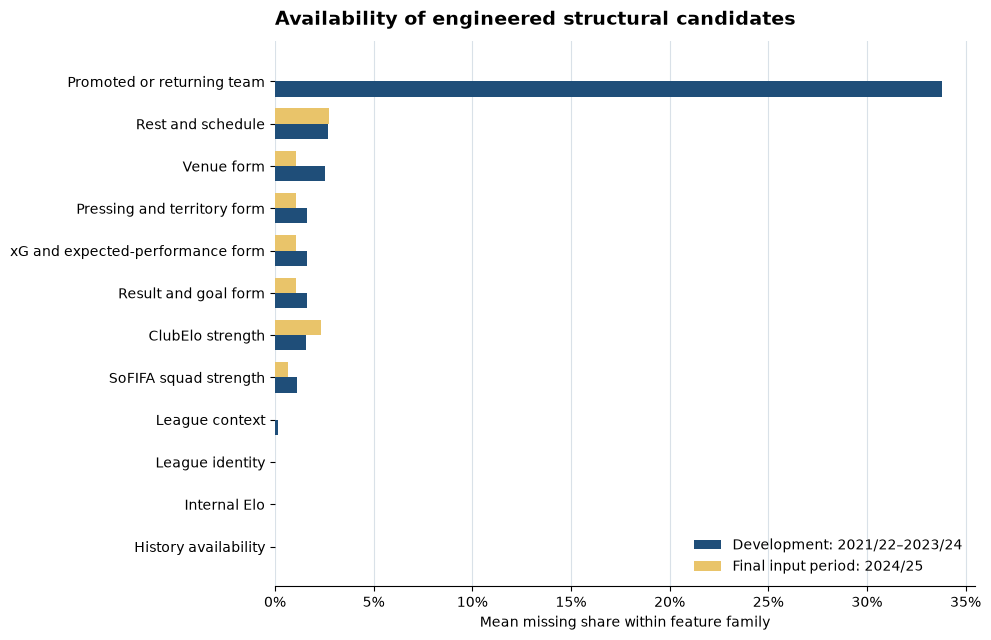

In [12]:
plot_missing = missing_summary.pivot(index="category", columns="sample_role", values="mean_missing_share")
plot_missing = plot_missing.sort_values("development")

fig, ax = plt.subplots(figsize=(10, 6.5))
y = np.arange(len(plot_missing))
height = 0.36
ax.barh(y - height / 2, plot_missing["development"], height, label="Development: 2021/22–2023/24", color="#1F4E79")
ax.barh(y + height / 2, plot_missing["walk_forward_test"], height, label="Final input period: 2024/25", color="#E9C46A")
ax.set_yticks(y, plot_missing.index)
ax.set_xlabel("Mean missing share within feature family")
ax.set_title("Availability of engineered structural candidates", loc="left", fontsize=14, fontweight="bold", pad=12)
ax.xaxis.set_major_formatter(lambda value, position: f"{value:.0%}")
ax.grid(axis="x", color="#D9E1E8", linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(frameon=False, loc="lower right")
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
plt.show()

The chart compares input availability, not model performance. Any difference in 2024/25 coverage will be handled by a pipeline fitted on development data; it will not be used to tune the feature definitions.

## 13. Short development-only EDA

This focused EDA asks whether several pre-match strength contrasts move in the expected direction across realised H/D/A outcomes. Only development seasons are shown. The plot is descriptive and does not select features.

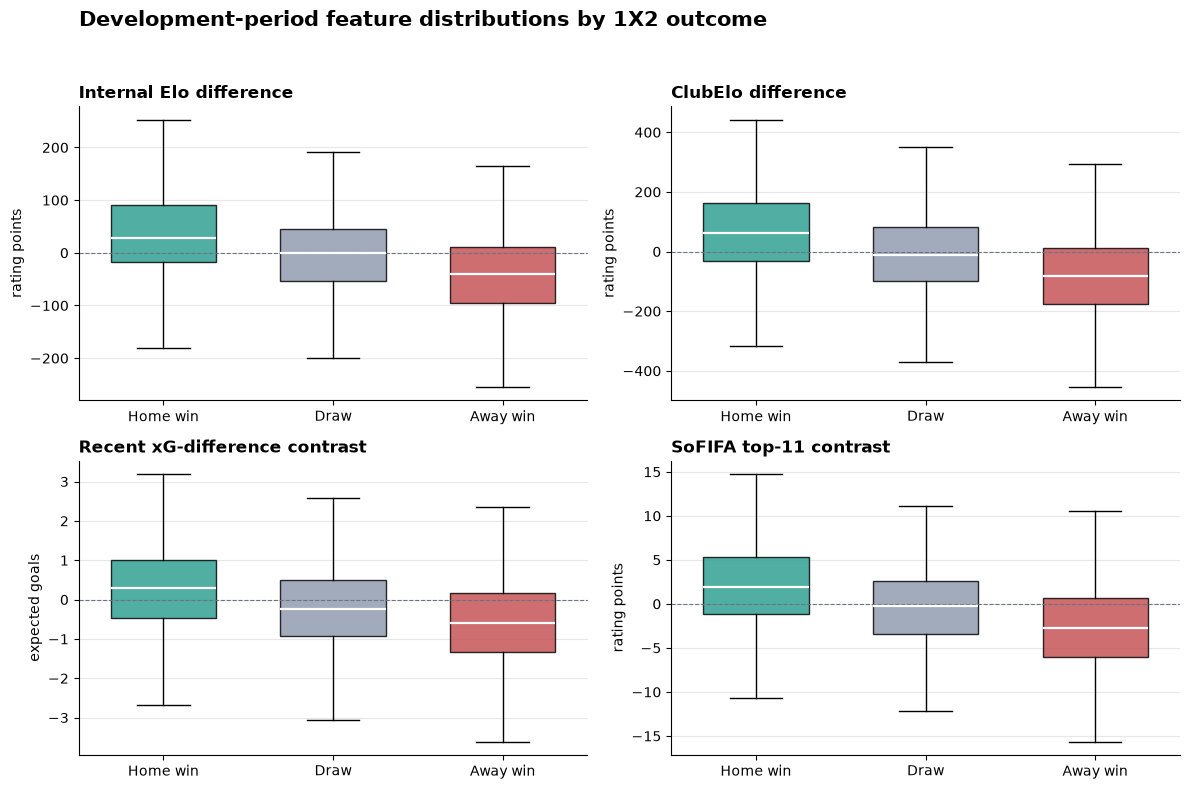

In [13]:
development = feature_table.loc[feature_table["sample_role"].eq("development")].copy()
eda_features = [
    ("elo_diff_pre", "Internal Elo difference", "rating points"),
    ("clubelo_diff", "ClubElo difference", "rating points"),
    ("diff_xg_diff_ewm_span_5", "Recent xG-difference contrast", "expected goals"),
    ("diff_sofifa_top11_overall", "SoFIFA top-11 contrast", "rating points"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (feature, title, unit) in zip(axes.flat, eda_features):
    groups = [development.loc[development["target_1x2"].eq(result), feature].dropna() for result in ["H", "D", "A"]]
    box = ax.boxplot(groups, tick_labels=["Home win", "Draw", "Away win"], patch_artist=True, showfliers=False, widths=0.62)
    for patch, result in zip(box["boxes"], ["H", "D", "A"]):
        patch.set_facecolor(CLASS_COLORS[result])
        patch.set_alpha(0.82)
    for median in box["medians"]:
        median.set_color("white")
        median.set_linewidth(1.6)
    ax.axhline(0, color="#6B7280", linewidth=0.8, linestyle="--")
    ax.set_title(title, loc="left", fontweight="bold")
    ax.set_ylabel(unit)
    ax.grid(axis="y", color="#E5E7EB", linewidth=0.8)
    ax.set_axisbelow(True)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

fig.suptitle("Development-period feature distributions by 1X2 outcome", x=0.07, ha="left", fontsize=15, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Positive home-minus-away contrasts should generally be higher for home wins and lower for away wins. Overlap is nevertheless substantial, which is consistent with the stochastic nature of football and explains why no single rating can determine the outcome. Draws are particularly difficult because their feature distributions often lie between, and overlap with, both win classes.

## 14. Save the candidate table

The persistent output is a single UTF-8 CSV. It contains identifiers, targets, source variables required for interpretation, and all candidate features. Selection status remains in the modelling notebooks and is not exported as a feature-manifest file.

In [14]:
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
output_path = PROCESSED_DATA_DIR / "match_features.csv"
feature_table.to_csv(output_path, index=False, encoding="utf-8", date_format="%Y-%m-%d")

print(f"Saved: {output_path}")
print(f"Rows: {len(feature_table):,}")
print(f"Columns: {feature_table.shape[1]}")
print(f"Structural candidates: {len(feature_sets['structural_full'])}")
print(f"Market candidates: {len(feature_sets['market_full'])}")
print(feature_table.groupby(["season_id", "sample_role"]).size().to_string())

Saved: C:\Users\cerve\Desktop\DP\match_prediction\data\processed\match_features.csv
Rows: 7,156
Columns: 284
Structural candidates: 229
Market candidates: 234
season_id  sample_role      
2021       development          1826
2022       development          1826
2023       development          1752
2024       walk_forward_test    1752


## 15. Conclusion

The feature table is limited to the fixed 2021/22–2024/25 experiment. Every performance state uses a shifted history, league context excludes the current calendar date, internal Elo is recorded before its result update, and external ratings respect their dated availability. Exact candidate inputs and their limitations are visible in the catalogue.

The candidate space is intentionally broader than a final model: it contains short and long form, absolute home and away levels, differences, rating systems, squad strength, and optional market probabilities. Notebook 03 will now remove invalid or unstable variables, control redundancy, apply shadow-feature relevance and RFE inside each chronological development fold, tune all multiclass algorithms, and print the exact features of every winning league-specific and pooled model.